In [1]:
import pandas as pd
import random
from rdkit import Chem
from rdkit.Chem import rdmolops
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Recap import RecapDecompose
from rdkit.Chem import Descriptors, QED
from itertools import permutations,combinations

In [2]:
# ------------------------- STEP 1: LOAD LIGANDS -------------------------
def load_ligands(csv_file):
    df = pd.read_csv(csv_file)
    if 'SMILES' not in df.columns:
        raise ValueError("CSV must contain a 'SMILES' column.")
    
    ligands = df['SMILES'].dropna().tolist()
    valid_ligands = [s for s in ligands if Chem.MolFromSmiles(s) is not None]
    return valid_ligands


In [3]:
# ------------------------- STEP 2: FLEXIBLE FRAGMENTATION -------------------------
def fragment_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return []

    fragments = set()

    # Murcko Core Extraction
    core = MurckoScaffold.GetScaffoldForMol(mol)
    if core and Chem.MolToSmiles(core) != smiles:
        fragments.add(Chem.MolToSmiles(core))
    
    # Recap Fragmentation (Break into functional groups)
    recap_tree = RecapDecompose(mol)
    recap_frags = recap_tree.GetAllChildren().keys()
    fragments.update(recap_frags)

    return filter_valid_fragments(fragments)

def filter_valid_fragments(fragments):
    """ Looser filtering to allow more substituents """
    valid_fragments = []
    for frag in fragments:
        mol = Chem.MolFromSmiles(frag)
        if not mol:
            continue

        # Ensure molecule is chemically valid
        try:
            Chem.SanitizeMol(mol)
        except:
            continue

        # Loosened validation rules:
        if is_partially_valid_structure(mol):
            valid_fragments.append(frag)

    return valid_fragments

def is_partially_valid_structure(mol):
    """ Less strict molecular validity checks """

    # Allow structures even if ring systems are incomplete
    # Allow unconnected functional groups (e.g., small alkyl chains)
    
    # Ensure reasonable valencies
    for atom in mol.GetAtoms():
        if atom.GetExplicitValence() > atom.GetTotalDegree() + 1:  # Allow slight over-valency
            return False  
    
    return True

def fragment_ligands(ligands):
    unique_fragments = set()
    for smiles in ligands:
        unique_fragments.update(fragment_molecule(smiles))
    
    return list(unique_fragments)



In [4]:
# ------------------------- STEP 3: SAVE UNIQUE FRAGMENTS -------------------------
def save_substituents_to_csv(substituents, output_file):
    df = pd.DataFrame({'SMILES': substituents})
    df.to_csv(output_file, index=False)

In [5]:
# ------------------------- STEP 4: GENERATE NEW LIGANDS WITH RELAXED RULES -------------------------
def generate_ligands(unique_substituents, num_molecules=10, num_substituents=2):
    if len(unique_substituents) < num_substituents:
        raise ValueError(f"Not enough unique substituents. Found {len(unique_substituents)}, but need at least {num_substituents}.")
    
    print(f"Generating ligands using {len(unique_substituents)} unique substituents.")

    new_ligands = set()
    possible_combinations = list(combinations(unique_substituents, num_substituents))

    print(f"Total possible combinations: {len(possible_combinations)}")  # Debugging
    
    for _ in range(min(num_molecules, len(possible_combinations))):
        selected_groups = random.choice(possible_combinations)
        new_smiles = f"OP({selected_groups[0]})({selected_groups[1]})({selected_groups[0]})"

        # Validate final ligand
        mol = Chem.MolFromSmiles(new_smiles)
        if mol and is_partially_valid_structure(mol):
            try:
                Chem.SanitizeMol(mol)
                if is_loosely_drug_like(mol):
                    new_ligands.add(new_smiles)  
            except:
                continue  

    print(f"Generated {len(new_ligands)} valid ligands.")  # Debugging
    return list(new_ligands)


def is_loosely_drug_like(mol):
    """ Relaxed drug-likeness criteria """
    
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    qed_score = QED.qed(mol)

    # Slightly wider range for logP
    if not (-3 <= logp <= 6):
        return False
    
    # Allow higher TPSA
    if tpsa > 180:
        return False

    # Lower QED threshold
    if qed_score < 0.2:
        return False

    return True

### Run the below multiple times to generate as many requried ligands based on their combinations

In [8]:
# ------------------------- EXECUTION PIPELINE -------------------------
if __name__ == "__main__":
    ligands_csv = "Ligands.csv"
    substituents_csv = "Unique_Substitutes.csv"
    new_ligands_csv = "Final_new_Ligands_try3.csv"

    ligands = load_ligands(ligands_csv)
    unique_substituents = fragment_ligands(ligands)
    save_substituents_to_csv(unique_substituents, substituents_csv)
    print(f"Saved {len(unique_substituents)} unique valid substituents.")

    new_ligands = generate_ligands(unique_substituents, num_molecules=500000, num_substituents=2)
    save_substituents_to_csv(new_ligands, new_ligands_csv)
    print(f"Generated {len(new_ligands)} new valid ligands.")

Saved 75 unique valid substituents.
Generating ligands using 75 unique substituents.
Total possible combinations: 2775


[16:59:24] SMILES Parse Error: syntax error while parsing: OP()(c1ccc(-c2cccc3c2PCO3)cc1)()
[16:59:24] SMILES Parse Error: check for mistakes around position 4:
[16:59:24] OP()(c1ccc(-c2cccc3c2PCO3)cc1)()
[16:59:24] ~~~^
[16:59:24] SMILES Parse Error: Failed parsing SMILES 'OP()(c1ccc(-c2cccc3c2PCO3)cc1)()' for input: 'OP()(c1ccc(-c2cccc3c2PCO3)cc1)()'
[16:59:24] SMILES Parse Error: syntax error while parsing: OP()(*c1c(-n2nccc2P(C(C)(C)C)C(C)(C)C)c(-c2ccccc2)nn1-c1ccccc1)()
[16:59:24] SMILES Parse Error: check for mistakes around position 4:
[16:59:24] OP()(*c1c(-n2nccc2P(C(C)(C)C)C(C)(C)C)c(-
[16:59:24] ~~~^
[16:59:24] SMILES Parse Error: Failed parsing SMILES 'OP()(*c1c(-n2nccc2P(C(C)(C)C)C(C)(C)C)c(-c2ccccc2)nn1-c1ccccc1)()' for input: 'OP()(*c1c(-n2nccc2P(C(C)(C)C)C(C)(C)C)c(-c2ccccc2)nn1-c1ccccc1)()'
[16:59:24] SMILES Parse Error: syntax error while parsing: OP()(*c1cccc2c1[P@@](C(C)(C)C)[C@H](C(C)C)O2)()
[16:59:24] SMILES Parse Error: check for mistakes around position 4:
[16:59

Generated 404 valid ligands.
Generated 404 new valid ligands.


In [13]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("Final_new_Ligands_try3.csv")

# Modify SMILES: Remove leading 'O' if followed by 'P'
df["SMILES"] = df["SMILES"].str.replace(r"^O(?=P)", "", regex=True)

# Save the modified CSV
df.to_csv("ligands_modified_try3.csv", index=False)

print("Modification complete! Saved as ligands_modified.csv")


Modification complete! Saved as ligands_modified.csv


In [14]:
import pandas as pd
from rdkit import Chem

def clean_ligands(input_csv, output_csv):
    df = pd.read_csv(input_csv)

    if 'SMILES' not in df.columns:
        raise ValueError("Input CSV must contain a 'SMILES' column.")

    valid_smiles = []
    phosphorus_counts = []

    for smiles in df['SMILES']:
        try:
            mol = Chem.MolFromSmiles(smiles, sanitize=False)
            if mol is None:
                continue  # skip invalid
            Chem.SanitizeMol(mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_KEKULIZE)
            p_count = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'P')
            if p_count <= 1:
                valid_smiles.append(smiles)
                phosphorus_counts.append(p_count)
        except:
            continue  # skip on any parsing error

    cleaned_df = pd.DataFrame({'SMILES': valid_smiles})
    cleaned_df.to_csv(output_csv, index=False)
    print(f"Cleaned dataset saved to: {output_csv}")


In [17]:
input_ = "ligands_modified_try3.csv"
output_ = "Filtered_new_Ligands_try3.csv"
clean_ligands(input_, output_)

Cleaned dataset saved to: Filtered_new_Ligands_try3.csv


In [18]:
import pandas as pd
import glob

# List of CSV files to merge
csv_files = ["Filtered_new_Ligands_try3.csv", "Filtered_new_Ligands_try2.csv","Filtered_new_Ligands_try1.csv"]  # Update with actual file names

# Read and concatenate files, keeping only the 'SMILES' column
df_list = [pd.read_csv(file, usecols=["SMILES"]) for file in csv_files]
merged_df = pd.concat(df_list, ignore_index=True)

# Save the merged DataFrame to a CSV file
merged_df.to_csv("Ligands_XGB.csv", index=False)

print("Merged file saved as Ligands_XGB.csv")


Merged file saved as Ligands_XGB.csv


In [21]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

def smiles_to_morgan_fp(smiles_list, radius=2, n_bits=1024):
    """Convert a list of SMILES to Morgan fingerprints. Skip invalid SMILES."""
    valid_smiles = []
    fingerprints = []
    generator = GetMorganGenerator(radius=radius, fpSize=n_bits)

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            try:
                fp = generator.GetFingerprint(mol)
                fingerprints.append(list(fp))
                valid_smiles.append(smi)
            except Exception as e:
                print(f"Warning: Could not generate fingerprint for SMILES: {smi} -> {e}")
        else:
            print(f"Warning: Invalid SMILES skipped: {smi}")

    return valid_smiles, fingerprints

def convert_smiles_csv_to_fingerprint(input_csv, output_csv, radius=2, n_bits=1024):
    df = pd.read_csv(input_csv)
    if 'SMILES' not in df.columns:
        raise ValueError("Input CSV must have a 'SMILES' column")

    valid_smiles, fps = smiles_to_morgan_fp(df['SMILES'], radius=radius, n_bits=n_bits)
    fp_df = pd.DataFrame(fps, columns=[f'Bit_{i}' for i in range(n_bits)])

    # Keep only rows corresponding to valid SMILES
    df_valid = df[df['SMILES'].isin(valid_smiles)].reset_index(drop=True)
    output_df = pd.concat([df_valid, fp_df], axis=1)

    output_df.to_csv(output_csv, index=False)
    print(f"Saved {n_bits}-bit Morgan fingerprints for {len(output_df)} valid SMILES to {output_csv}")



In [23]:
convert_smiles_csv_to_fingerprint("Ligands_XGB.csv", "Morgan_XGB.csv", radius=2, n_bits=1024)

[17:08:31] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 17
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 17
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 8 9 16 17 18
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 8 9 16 17 18
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 23
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 9 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 9 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 13 14 21 22 23
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 9 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 17
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 10 11
[17:08:31] Can't kekulize mol.  Unkekulize

Saved 1024-bit Morgan fingerprints for 359 valid SMILES to Morgan_XGB.csv


[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 7 8 9 16 17
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 7 8 9 16 17
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 18 19 20 21 22
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 17
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 10 11
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 7 8 9 16 17
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 18 19 20 27 28
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 13 14 21 22 23
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 21
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[17:08:31] Can't kekulize mol.  Unkekulized atoms: 1 2 9 10 11
[17:08:31] Can't kekulize mol.  Unkekulize

In [24]:
import pandas as pd

# Load the final CSV with fingerprints
df = pd.read_csv("Morgan_XGB.csv")

# Extract only fingerprint columns (they start with 'Bit_')
fp_columns = [col for col in df.columns if col.startswith("Bit_")]
morgan_XGB = df[fp_columns].copy()

# Rename columns to F_1, F_2, ..., F_1024
morgan_XGB.columns = [f'F_{i+1}' for i in range(len(morgan_XGB.columns))]

# Preview
print(morgan_XGB.head())


   F_1  F_2  F_3  F_4  F_5  F_6  F_7  F_8  F_9  F_10  ...  F_1015  F_1016  \
0    0    1    0    0    0    0    0    0    0     0  ...       0       0   
1    0    0    0    0    0    0    0    0    0     0  ...       0       0   
2    0    0    0    0    0    0    0    0    0     0  ...       0       0   
3    0    0    0    0    0    0    0    0    0     0  ...       0       0   
4    0    0    0    0    0    0    0    0    0     0  ...       0       0   

   F_1017  F_1018  F_1019  F_1020  F_1021  F_1022  F_1023  F_1024  
0       0       0       0       0       0       0       0       0  
1       0       0       0       0       0       0       0       0  
2       0       0       0       0       0       0       0       0  
3       0       0       0       0       0       0       0       0  
4       0       0       0       0       0       0       0       0  

[5 rows x 1024 columns]


In [25]:
import os
import logging
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
import optuna

In [27]:
import os
import xgboost as xgb
import pandas as pd
import numpy as np

# Load your fingerprint input
# morgan_XGB = pd.read_csv("Morgan_XGB.csv")

# Ensure only Morgan bit columns are selected
bit_cols = [col for col in morgan_XGB.columns if col.startswith("F_")]
morgan_XGB = morgan_XGB[bit_cols].astype(np.float32)

# Directory with saved models
model_dir = "models_xgboost_bayes_val_cv"

# Get all model filenames and extract feature names
model_files = [f for f in os.listdir(model_dir) if f.startswith("model_") and f.endswith(".pkl")]
descriptor_names = [f.replace("model_", "").replace(".pkl", "") for f in model_files]

# Predict for each descriptor
predictions = {}




In [28]:
print(descriptor_names)

['dipolemoment_boltz', 'dipolemoment_delta', 'dipolemoment_max', 'dipolemoment_min', 'dipolemoment_vburminconf', 'efgtens_xx_P_boltz', 'efgtens_yy_P_boltz', 'efgtens_zz_P_boltz', 'efg_amp_P_boltz', 'E_oxidation_boltz', 'E_reduction_boltz', 'E_solv_cds_boltz', 'E_solv_elstat_boltz', 'E_solv_total_boltz', 'fmo_eta_boltz', 'fmo_e_homo_boltz', 'fmo_e_lumo_boltz', 'fmo_mu_boltz', 'fmo_omega_boltz', 'fukui_m_boltz', 'fukui_p_boltz', 'nbo_bds_e_avg_boltz', 'nbo_bds_e_min_boltz', 'nbo_bds_occ_avg_boltz', 'nbo_bds_occ_max_boltz', 'nbo_bd_e_avg_boltz', 'nbo_bd_e_max_boltz', 'nbo_bd_occ_avg_boltz', 'nbo_bd_occ_min_boltz', 'nbo_lp_P_e_boltz', 'nbo_lp_P_occ_boltz', 'nbo_lp_P_percent_s_boltz', 'nbo_P_boltz', 'nbo_P_ra_boltz', 'nbo_P_rc_boltz', 'nmrtens_sxx_P_boltz', 'nmrtens_syy_P_boltz', 'nmrtens_szz_P_boltz', 'nmr_P_boltz', 'nuesp_P_boltz', 'Pint_dP_boltz', 'Pint_P_int_boltz', 'Pint_P_max_boltz', 'Pint_P_min_boltz', 'pyr_alpha_boltz', 'pyr_alpha_delta', 'pyr_alpha_max', 'pyr_alpha_min', 'pyr_alpha

In [29]:
print(morgan_XGB)

     F_1  F_2  F_3  F_4  F_5  F_6  F_7  F_8  F_9  F_10  ...  F_1015  F_1016  \
0    0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     0.0     0.0   
1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     0.0     0.0   
2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     0.0     0.0   
3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     0.0     0.0   
4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     0.0     0.0   
..   ...  ...  ...  ...  ...  ...  ...  ...  ...   ...  ...     ...     ...   
354  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     1.0     0.0   
355  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     1.0     0.0   
356  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     0.0     0.0   
357  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     0.0     0.0   
358  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...     0.0     0.0   

     F_1017  F_1018  F_1019  F_1020  F_1021  F_1022

In [31]:
import os
import xgboost as xgb
import pandas as pd
import numpy as np

# Load fingerprint data
# morgan_XGB = pd.read_csv("fingerprinted_output.csv")
bit_cols = [col for col in morgan_XGB.columns if col.startswith("F_")]
morgan_XGB = morgan_XGB[bit_cols].astype(np.float32)

# Must align row-wise with morgan_XGB
original_df = pd.read_csv("Morgan_XGB.csv")

# Model directory
model_dir = "models_xgboost_bayes_val_cv"
model_files = [f for f in os.listdir(model_dir) if f.startswith("model_") and f.endswith(".pkl")]
descriptor_names = [f.replace("model_", "").replace(".pkl", "") for f in model_files]

predictions = {}
skipped = []

for feature in descriptor_names:
    model_path = os.path.join(model_dir, f"model_{feature}.pkl")
    model = xgb.XGBRegressor()
    try:
        model.load_model(model_path)
        pred = model.predict(morgan_XGB)
        predictions[feature] = pred
    except Exception as e:
        print(f"❌ Skipping model '{feature}' due to error: {e}")
        skipped.append(feature)

# Create output
pred_df = pd.DataFrame(predictions)
pred_df.to_csv("predicted_descriptors.csv", index=False)


# ✅ Add SMILES and save version with it
pred_df_with_smiles = original_df[['SMILES']].copy()
pred_df_with_smiles = pd.concat([pred_df_with_smiles, pred_df], axis=1)
pred_df_with_smiles.to_csv("predicted_descriptors_with_smiles.csv", index=False)

print(f"✅ Saved predictions for {len(pred_df.columns)} descriptors.")
if skipped:
    print(f"⚠️ Skipped {len(skipped)} models due to mismatch or loading errors: {skipped}")

print(f"✅ Saved predictions for {len(pred_df.columns)} descriptors.")
if skipped:
    print(f"⚠️ Skipped {len(skipped)} models due to mismatch or loading errors: {skipped}")



✅ Saved predictions for 190 descriptors.
✅ Saved predictions for 190 descriptors.


In [32]:
pred_df.head()

,dipolemoment_boltz,dipolemoment_delta,dipolemoment_max,dipolemoment_min,dipolemoment_vburminconf,efgtens_xx_P_boltz,efgtens_yy_P_boltz,efgtens_zz_P_boltz,efg_amp_P_boltz,E_oxidation_boltz,...,vbur_ratio_vbur_vtot_boltz,vbur_vbur_boltz,vbur_vbur_delta,vbur_vbur_max,vbur_vbur_min,vbur_vbur_vburminconf,vbur_vtot_boltz,vmin_r_boltz,vmin_vmin_boltz,volume_boltz
0,0.883542,1.119187,1.956963,0.846197,1.728523,-0.842165,-0.650585,1.468032,1.814745,0.254526,...,0.233045,85.468857,27.869596,90.001839,59.531990,60.355572,330.028381,1.783610,-0.055064,397.838531
1,3.601101,2.746757,3.848183,1.653122,3.205452,-1.071156,-0.498768,1.554530,1.887761,0.256783,...,0.220631,98.104919,14.106120,102.835388,82.801300,77.535370,422.662201,1.811474,-0.065044,532.770142
2,3.055342,1.971097,3.936331,1.865636,3.313282,-0.775995,-0.687175,1.531199,1.865935,0.270600,...,0.134351,53.226650,4.235451,55.676205,57.144627,60.378136,432.639160,1.869310,-0.043979,478.095001
3,1.400922,0.403078,1.687863,1.369296,1.862820,-0.745708,-0.680008,1.442415,1.777855,0.246978,...,0.133548,56.862209,2.115220,50.598984,55.789635,56.784340,402.709412,1.844232,-0.047623,435.072998
4,2.377824,1.956240,3.396032,1.060037,2.550471,-0.806805,-0.713788,1.525172,1.878876,0.251546,...,0.188398,69.062454,14.233463,79.125214,62.400501,58.682999,423.079193,1.843379,-0.066002,467.381042


In [33]:
import pandas as pd

# Load the Excel file
df_thresh = pd.read_excel("Top_22_Features_Threshold.xlsx")  # Or pd.read_excel() if it's .xlsx

# Remove 'model_' prefix
df_thresh['feature'] = df_thresh['feature'].str.replace(r'^model_', '', regex=True)

# Extract just the first two columns
threshold_df = df_thresh[['feature', 'best_threshold']]


In [34]:
import pandas as pd

# Load your original CSV
df = pd.read_csv("predicted_descriptors_with_smiles.csv")

# Choose the feature you want to keep (e.g., 'Col23' or actual column name like 'MolWt')
selected_feature = "vbur_far_vtot_boltz"  # Replace with the actual name of the feature you want

# Create a new DataFrame with only 'smiles' and the selected feature
df_selected = df[['SMILES', selected_feature]]

# Save the new CSV
df_selected.to_csv("smiles_and_selected_feature.csv", index=False)


In [35]:
# Load predicted descriptors
pred_df = pd.read_csv("predicted_descriptors.csv")

# Keep only relevant 22 descriptors
filtered_pred_df = pred_df[threshold_df['feature'].tolist()]


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# Make a directory to save plots
import os
# Make a directory to save plots
os.makedirs("descriptor_plots", exist_ok=True)  # <- Match the name used in plt.savefig

# Iterate and plot
for feature, threshold in zip(threshold_df['feature'], threshold_df['best_threshold']):
    values = filtered_pred_df[feature]
    
    # Create color labels
    colors = ['red' if val > threshold else 'blue' for val in values]

    plt.figure(figsize=(10, 4))
    plt.scatter(range(len(values)), values, c=colors, alpha=0.7)
    plt.axhline(threshold, color='green', linestyle='--', label=f'Threshold = {threshold:.2f}')
    plt.title(f'{feature}: Values above/below threshold')
    plt.xlabel('Data Point Index')
    plt.ylabel('Predicted Value')
    plt.legend()
    plt.tight_layout()
    
    # Save each plot
    plt.savefig(f'descriptor_plots/{feature}.png')
    plt.close()

print("Plots saved to 'descriptor_plots' directory.")


Plots saved to 'descriptor_plots' directory.


In [39]:
import pandas as pd

# Load threshold and prediction data
threshold_df = pd.read_excel('Top_22_Features_Threshold.xlsx')  # Replace with actual filename
predictions_df = pd.read_csv('predicted_descriptors.csv')  # Has 22 descriptor columns
original_df = pd.read_csv('Morgan_XGB.csv')  # Has 'SMILES' + F_1, F_2, ...

# Step 1: Clean threshold feature names
threshold_df['feature'] = threshold_df['feature'].str.replace('model_', '', regex=False)

# Step 2: Select the target feature
feature = 'vbur_far_vtot_boltz'
threshold = threshold_df.loc[threshold_df['feature'] == feature, 'best_threshold'].values[0]

# Step 3: Find rows where predicted feature value > threshold
indices = predictions_df[predictions_df[feature] >= threshold].index

# Step 4: Extract SMILES and predicted value
filtered_df = original_df.loc[indices, ['SMILES']].copy()
filtered_df[feature] = predictions_df.loc[indices, feature].values



In [40]:
filtered_df.head()

,SMILES,vbur_far_vtot_boltz
1,COC1=CC=C(N2C(P(C(C)(C)C)C(C)(C)C)=CC=N2)C(OC)=C1,86.010155
5,P(c1c(OC)cccc1OC)(c1ccc(C2(c3ccccc3)CC2)cc1)(c...,38.933370
6,P(c1c(OC)cccc1OC)(n1nc(-c2ccccc2)cc1-c1ccccc1)...,47.088684
8,P(c1c(OC(C)C)cccc1OC(C)C)(c1nn(-c2ccccc2)cc1)(...,71.397680
10,P(c1nn(-c2ccccc2)c(-c2ccccc2)c1)(c1ccccc1N(C)C...,66.780930


In [41]:

# Step 5 (optional): Save the filtered SMILES
filtered_df.to_csv(f'smiles_over_threshold_{feature}_2.csv', index=False)

print(f"{len(filtered_df)} molecules found with {feature} > {threshold:.4f}")

141 molecules found with vbur_far_vtot_boltz > 28.5223


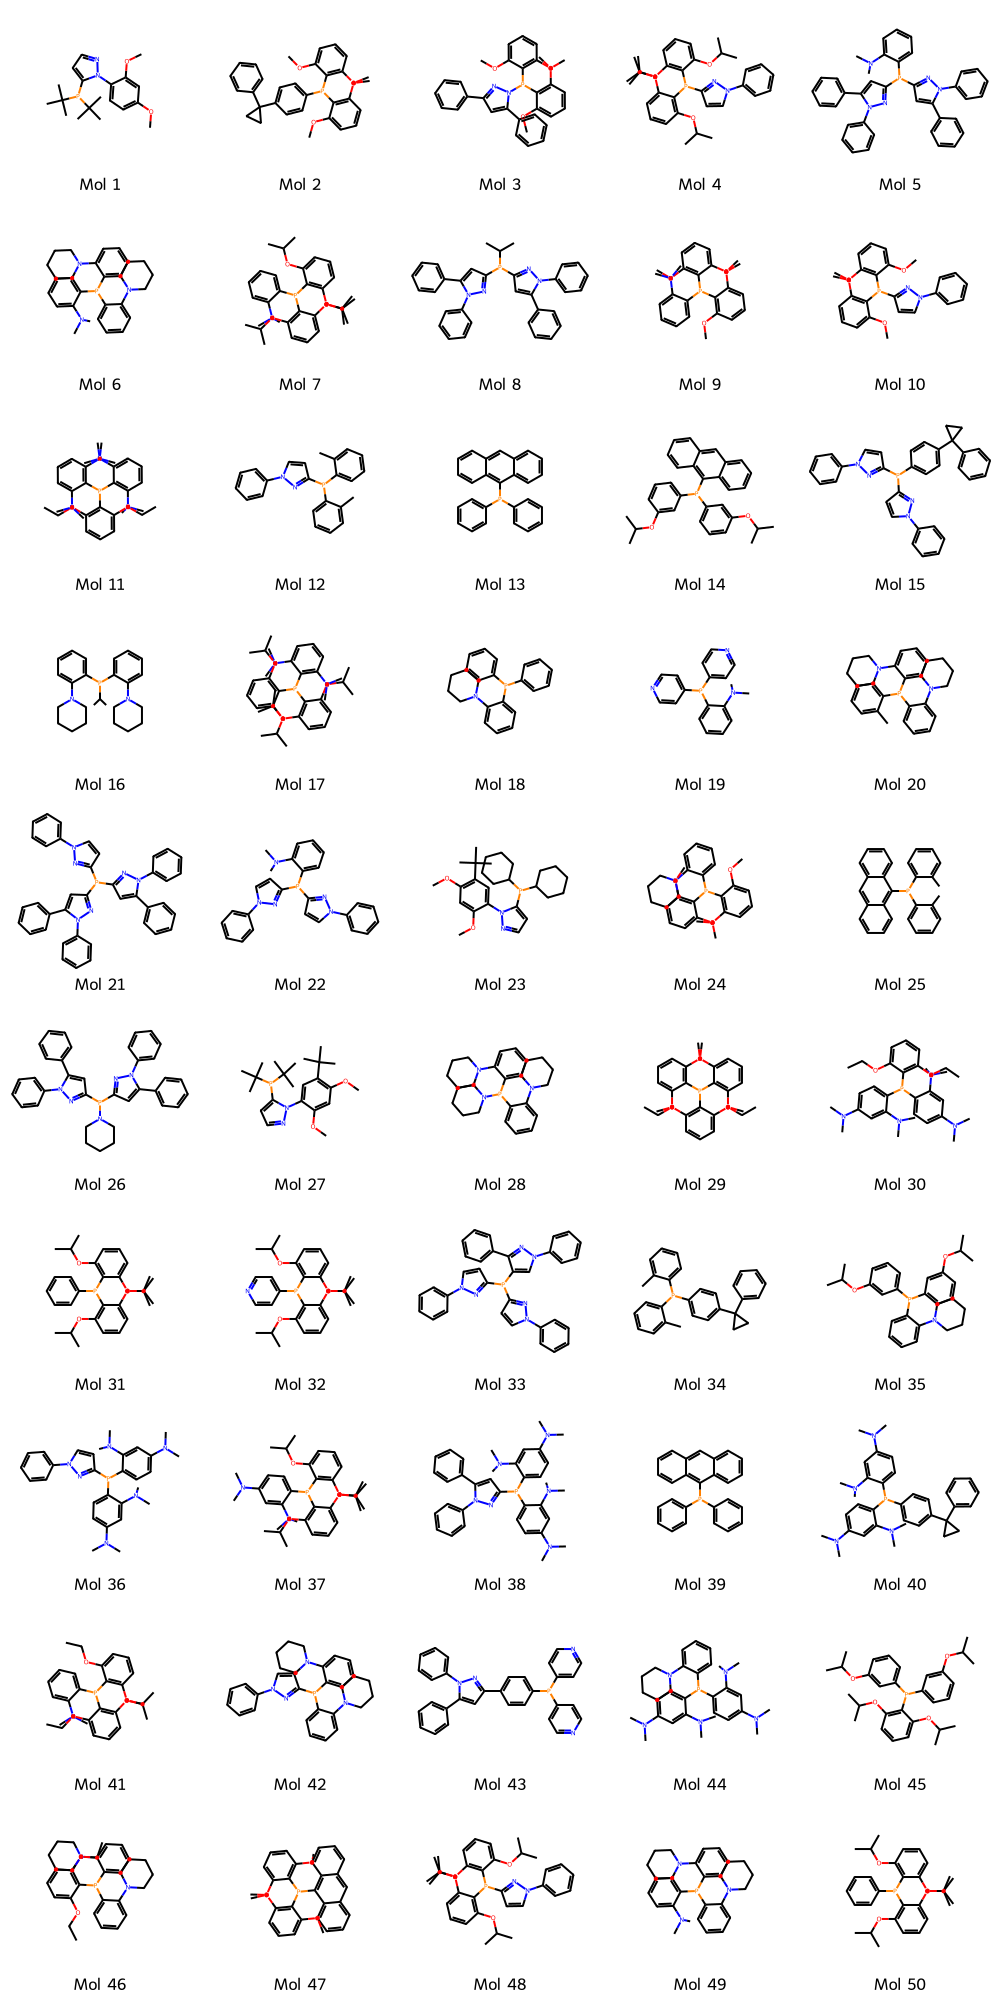

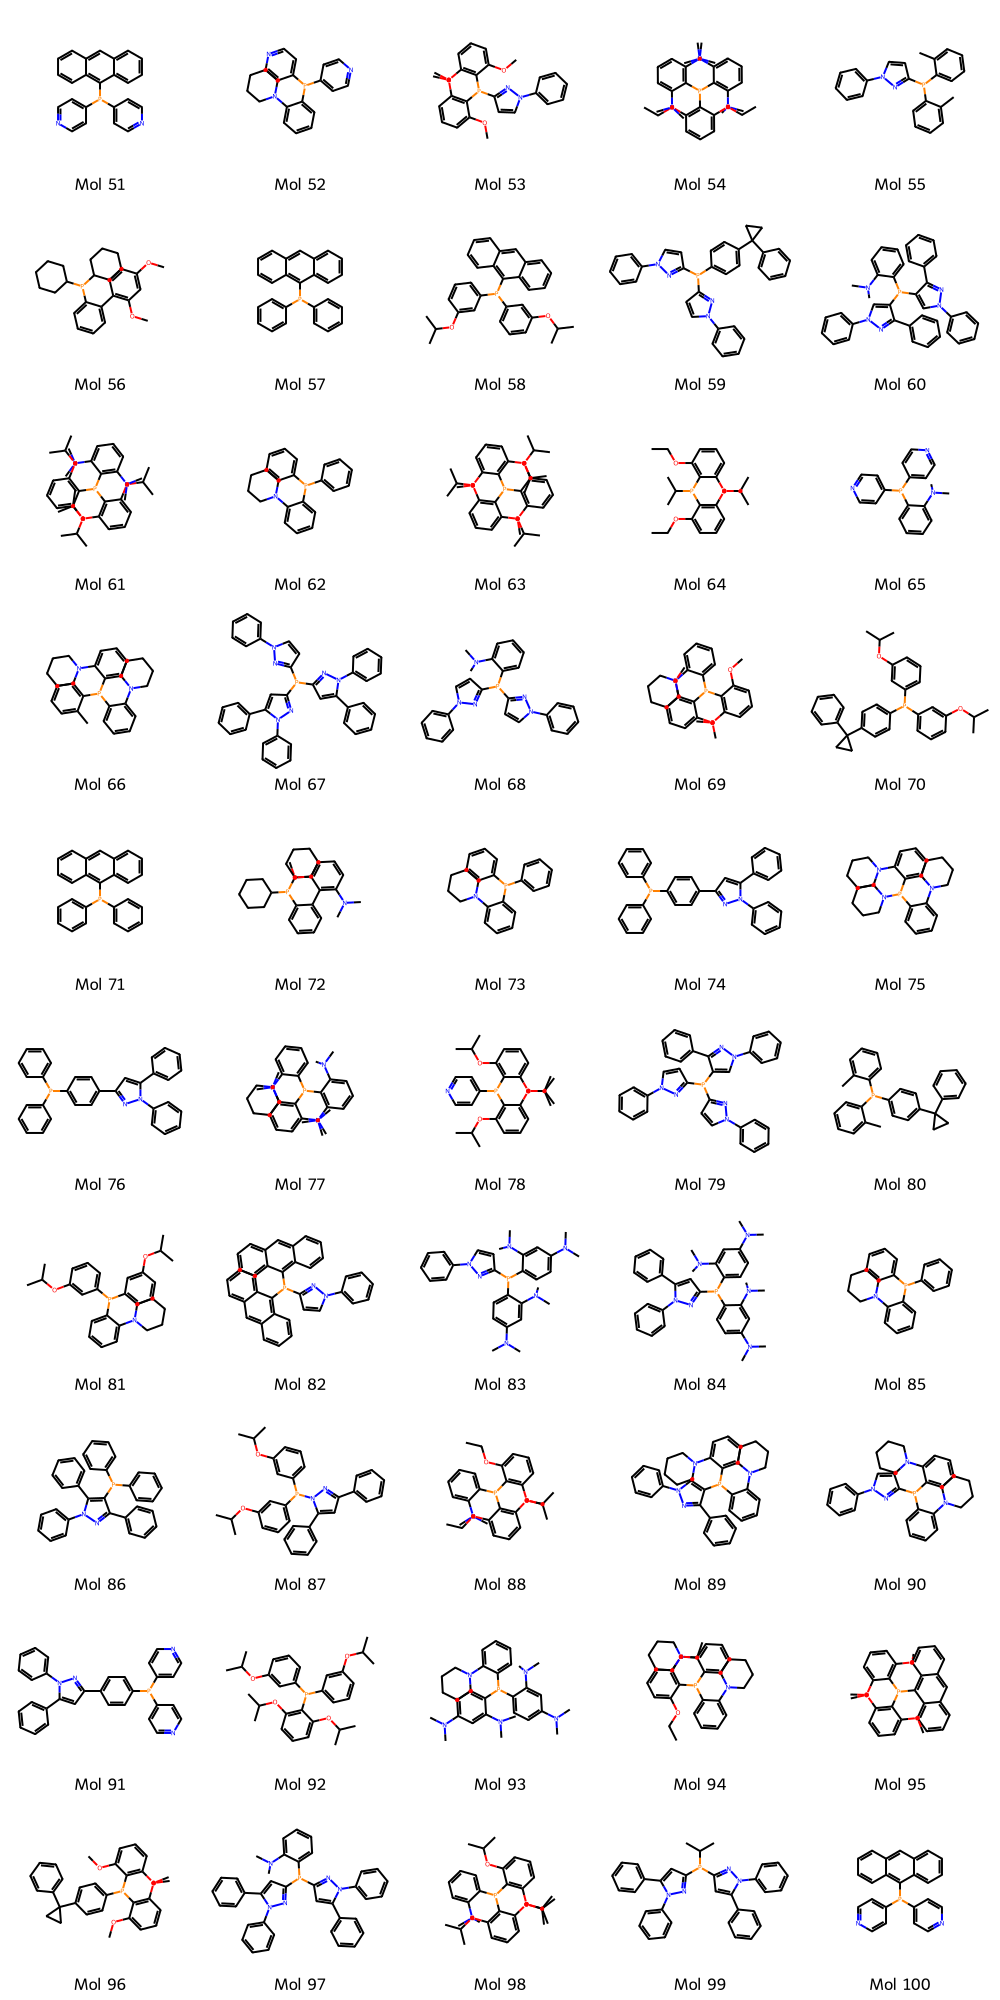

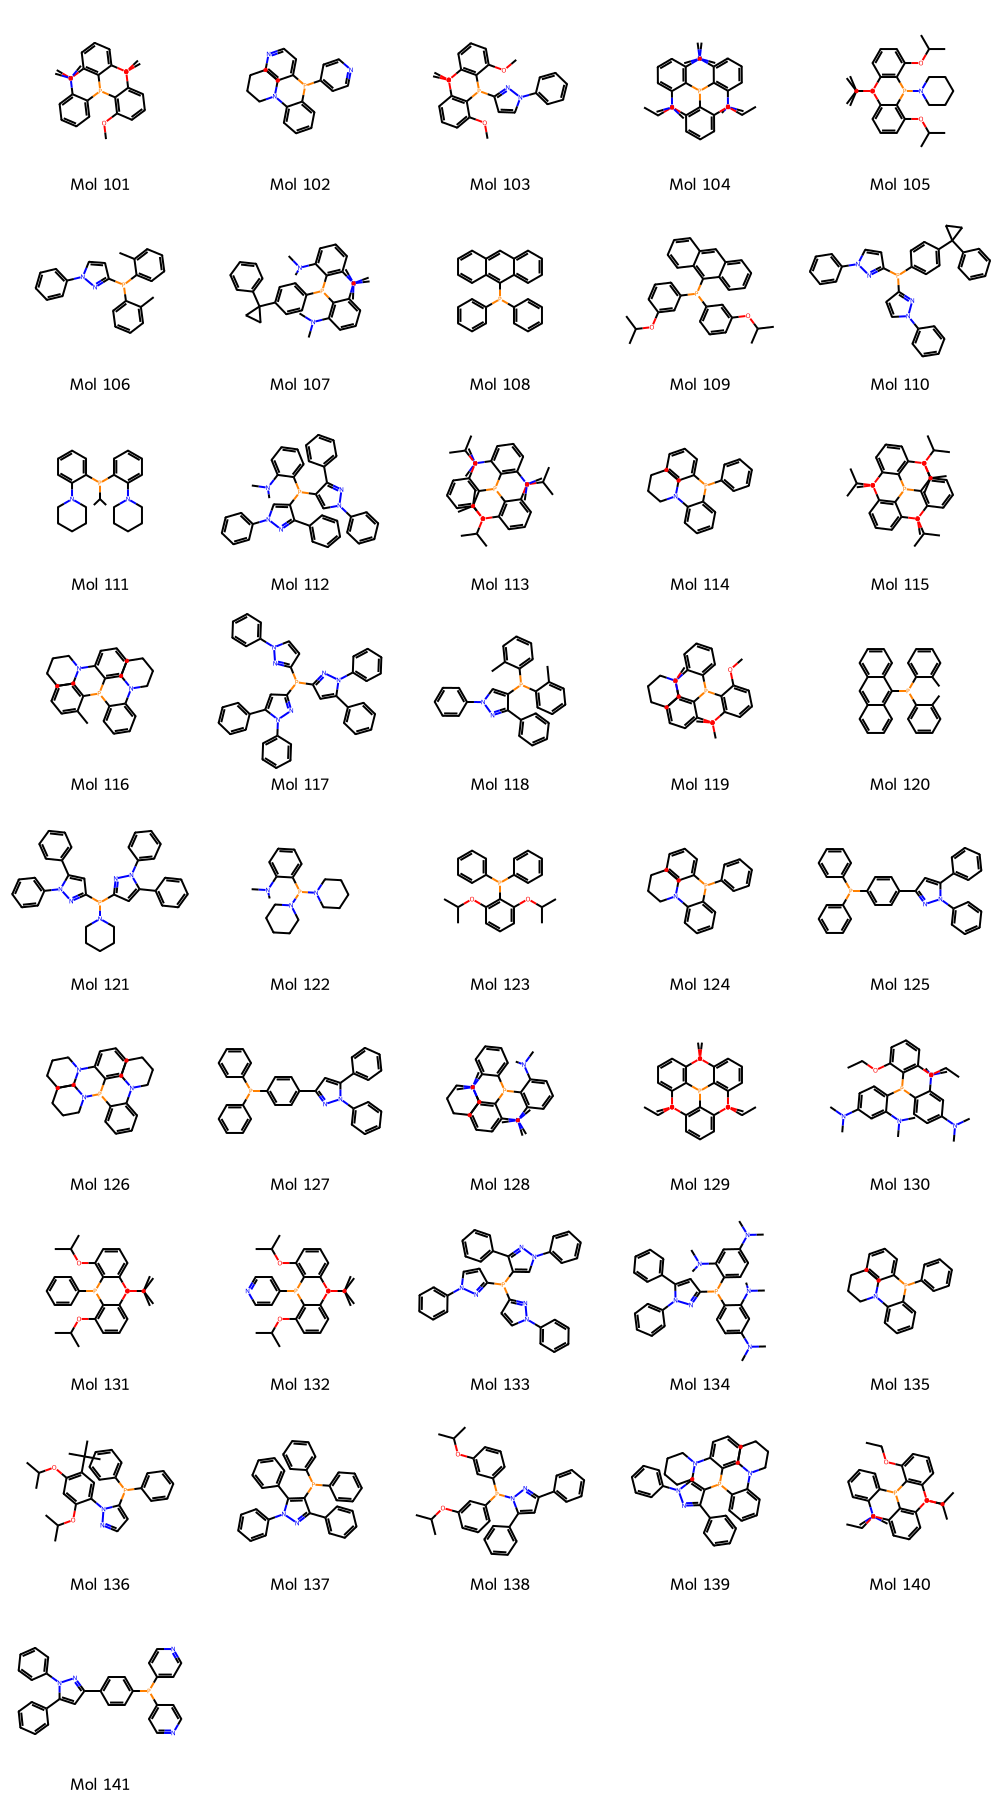

In [43]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# ------------------ Load Ligands from CSV ------------------
csv_file = f"smiles_over_threshold_{feature}_2.csv"  # Update with your file name

df = pd.read_csv(csv_file)

# Ensure the column name is correct
if 'SMILES' not in df.columns:
    raise ValueError("CSV must contain a 'SMILES' column.")

smiles_list = df['SMILES'].dropna().tolist()

# ------------------ Display Molecular Structures in Batches ------------------
molecules = [Chem.MolFromSmiles(smiles) for smiles in smiles_list if Chem.MolFromSmiles(smiles)]
batch_size = 50  # Display 50 molecules at a time

for i in range(0, len(molecules), batch_size):
    batch = molecules[i:i+batch_size]
    
    img = Draw.MolsToGridImage(
        batch, 
        molsPerRow=5, 
        subImgSize=(200, 200), 
        legends=[f"Mol {j+1}" for j in range(i, i+len(batch))]
    )
    
    display(img)


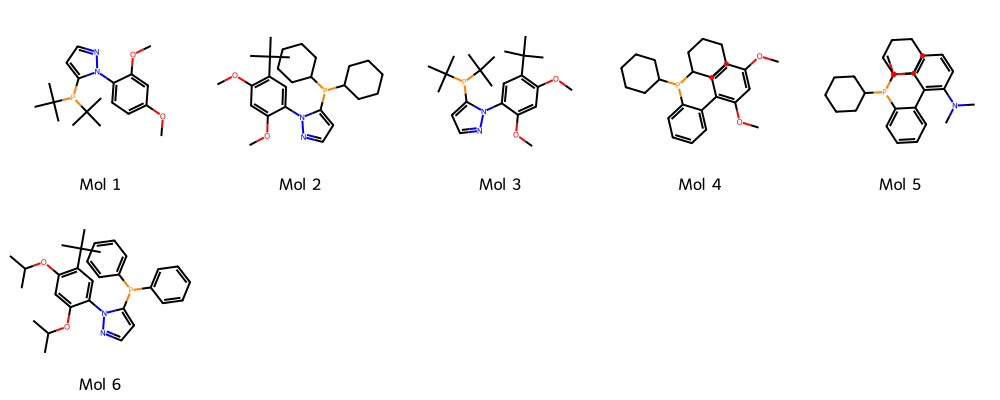

In [46]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# ------------------ Load Ligands from CSV ------------------
excel_file = f"High_ligands_final.xlsx"  # Update with your file name

df = pd.read_excel(excel_file)

# Ensure the column name is correct
if 'SMILES' not in df.columns:
    raise ValueError("CSV must contain a 'SMILES' column.")

smiles_list = df['SMILES'].dropna().tolist()

# ------------------ Display Molecular Structures in Batches ------------------
molecules = [Chem.MolFromSmiles(smiles) for smiles in smiles_list if Chem.MolFromSmiles(smiles)]
batch_size = 50  # Display 50 molecules at a time

for i in range(0, len(molecules), batch_size):
    batch = molecules[i:i+batch_size]
    
    img = Draw.MolsToGridImage(
        batch, 
        molsPerRow=5, 
        subImgSize=(200, 200), 
        legends=[f"Mol {j+1}" for j in range(i, i+len(batch))]
    )
    
    display(img)
